In [2]:

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
import casadi as ca
import numpy as np

**Poço Eikram**


In [9]:
    # Parametros
M = 0.028# Massa molar do gás [kg/mol]
Ta = 301 # Temperatura da região anular [K]
La = 1500  # Comprimento da região anular [m]
ro = 1000# Densidade do óleo no reservatório [kg/m³]
Tw = 305 # Temperatura no tubo [K]
Lw = 1500  # Comprimento do tubo [m]
Lr = 500  # Distância do reservatório até o ponto de injeção [m]
  # Área da seção transversal abaixo do ponto injeção [m²]
 # Área da seção transversal acima do ponto injeção [m²]
Hw = 1500  # [m]  

Dw= 0.121
Dr =0.121
u= 1# Exemplo de valor para u
u1= 50**(u - 1) 

Dbh = 0.121
Da = 0.189
Hr = 500
Hbh = 500
Lbh = 500
Tr = 301
PI = 0.22e-5
Cpc = 2e-3 # [m²]
Civ =  10e-4   # [m²]
Cr = 2.6e-4  # [m²]
Crh = 10e-3
Pr = 15e6  # Pressão no reservatório longe da cabeça do poço [Pa]
Ps = 2e6 # Pressão no manifold [Pa]

vo = 1 / ro  # Volume específico do óleo  
g = 9.81  # Aceleração da gravidade [m/s²]
Riser_p_fric = 0.5
R = 8.314  # Constante dos gases [J/mol.K]
GOR =0.1
dp_t_fric = 1.0e5 #'atm';
dp_bh_fric = 5.0e4 #'atm';

Ha = 1000
# Cálculo das áreas
Aw = (ca.pi * (Dw ** 2)) / 4  # Área da seção transversal do poço [m²]
Aa = (ca.pi * (Da ** 2)) / 4 - (ca.pi * (Dw ** 2)) / 4  # Área da seção transversal do anel [m²]
Ar = (ca.pi * (Dr ** 2)) / 4  # Área da seção transversal abaixo do ponto de injeção [m²]
Va = La * Aa  # Volume da região anular [m³]versal abaixo do ponto de injeção [m²]
Abh = (ca.pi * (Dbh ** 2)) / 4

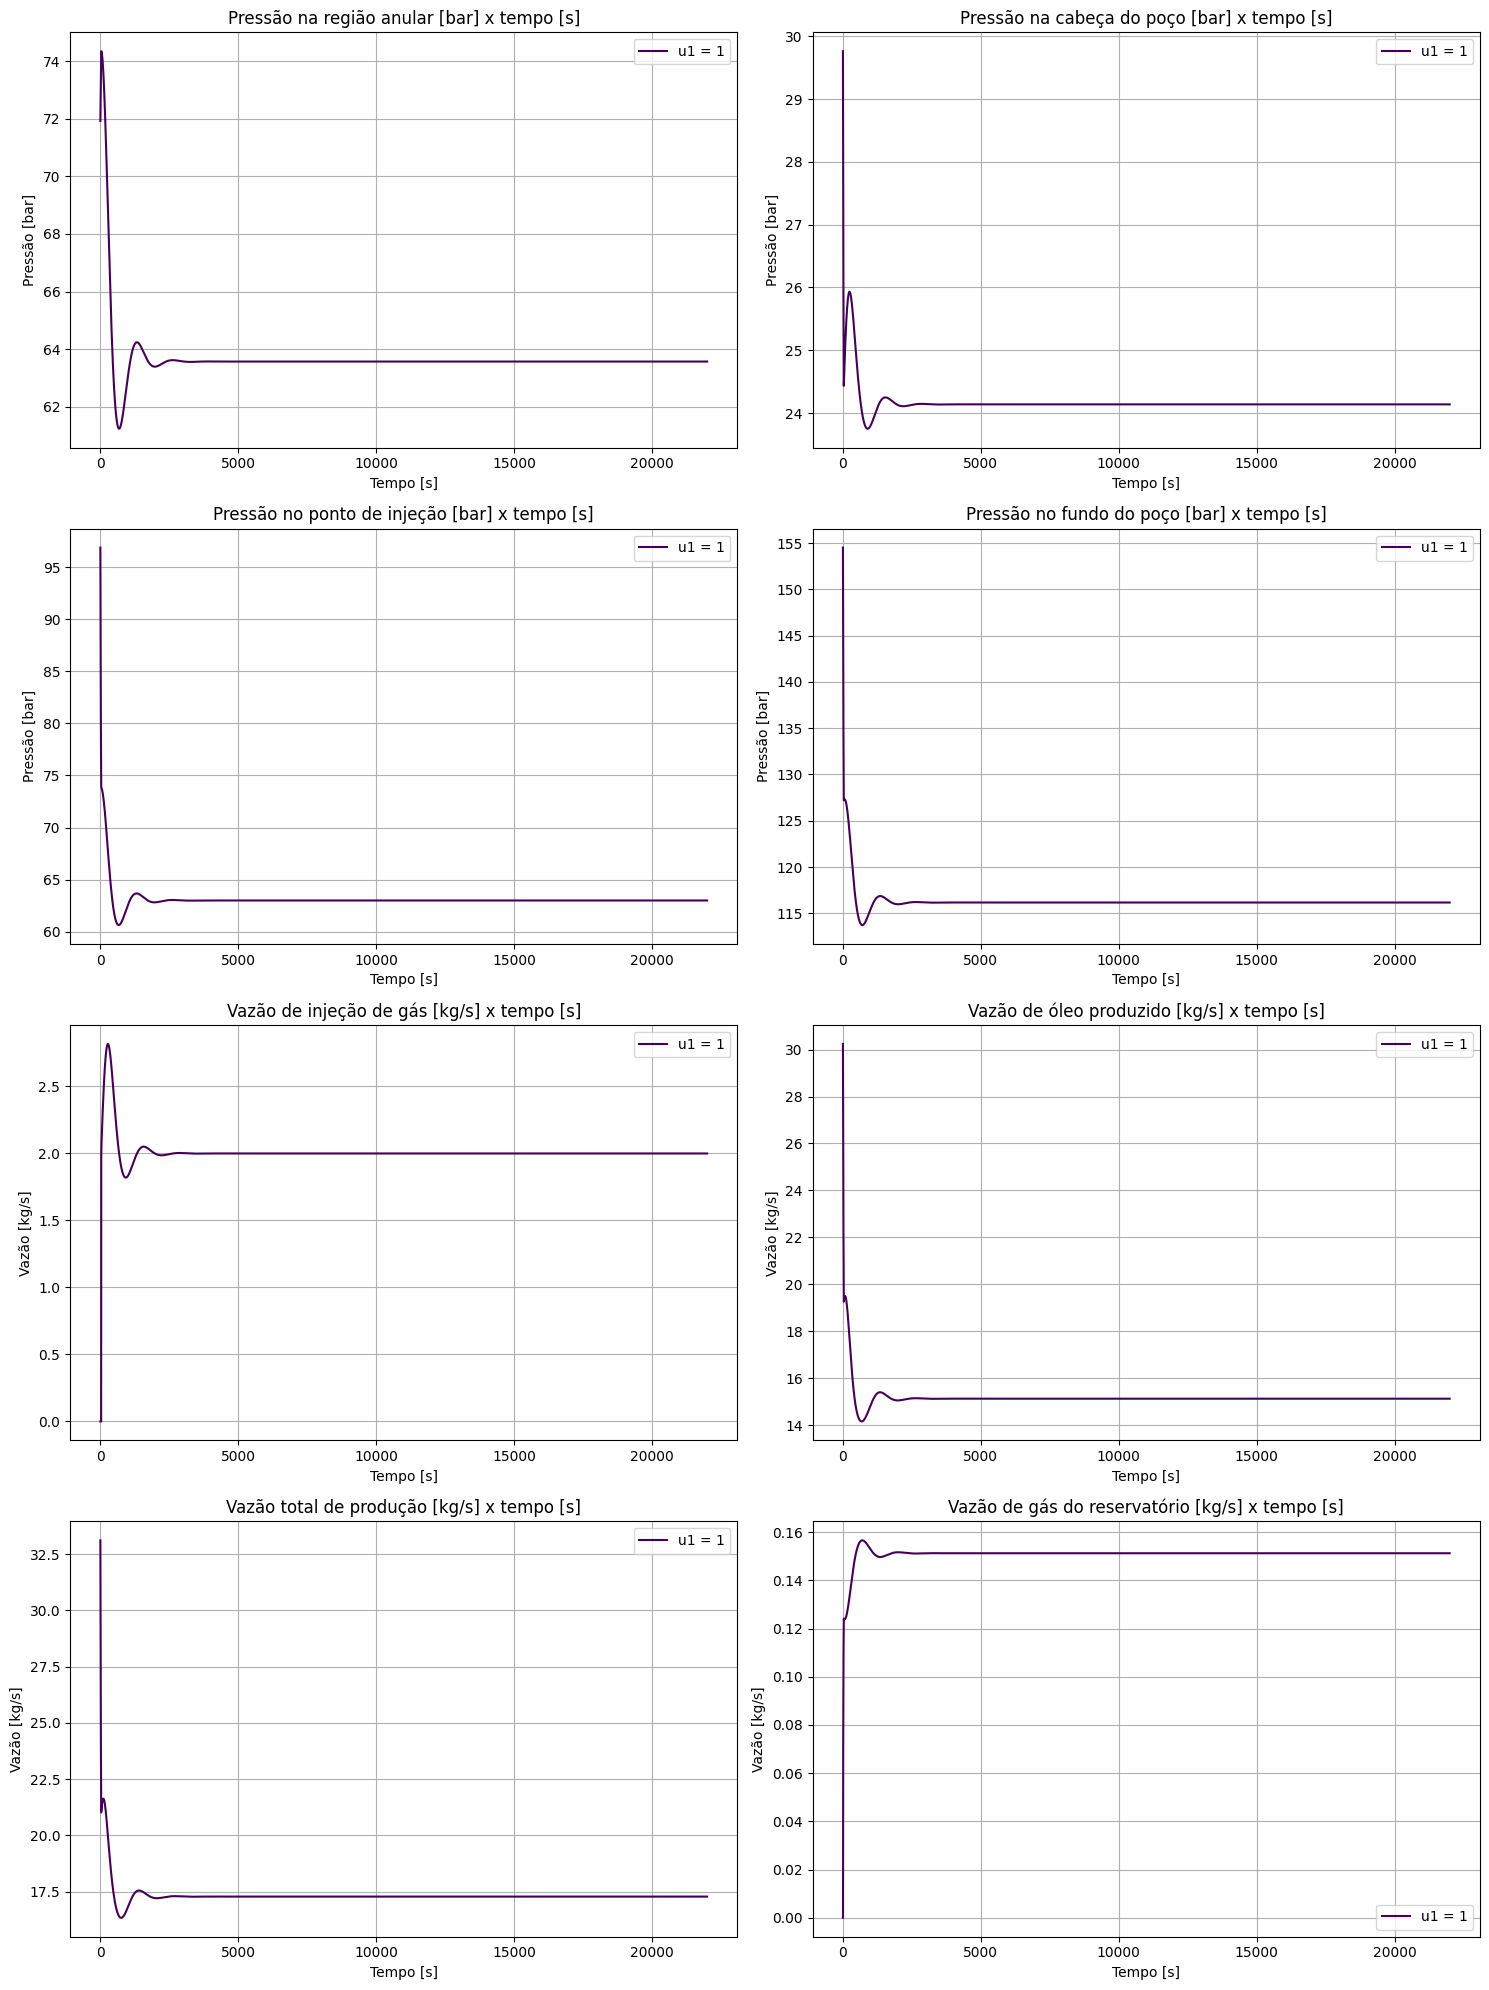

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca

# ==============================================================================
# Função do modelo dinâmico (ODE)
# ==============================================================================
def fun(t, x, par, u1, GOR):
    # Estados
    x1, x2, x3 = x[0], x[1], x[2]

    # Cálculos das pressões
    Pai = ((R * Ta / (Va * M)) + ((g * La)/Va)) * x1
    Pwh = (R * Tw / M) * (x2 / (Lw * Aw - (vo * x3)))
    
    D = np.sqrt(Aw * 4 / np.pi)
    ro_w = (x2 + x3) / (Lw * Aw)
    y3 = ca.fmax(0, (Pwh - Ps))
    
    # Cálculo da vazão usando u1 (a abertura da válvula)
    wpc = Cpc * ca.sqrt(ro_w * y3) * 50**(u1 - 1) 
    mu_oil = 0.001  # [Pa·s] - SUA VISCOSIDADE
    
    # Velocidade
    veloc = wpc / (ro_w * Aw + 1e-9)
    D = ca.sqrt(Aw * 4 / np.pi)
    
    # Viscosidade da mistura (considerando gás)
    mi_gas = 0.015e-3  # 0.015 cP
    frac_oil = x3 / (x2 + x3 + 1e-9)
    frac_gas = x2 / (x2 + x3 + 1e-9)
    mi_m = frac_oil * mu_oil + frac_gas * mi_gas
    
    # Reynolds (será ALTÍSSIMO com μ pequeno)
    Re = ro_w * veloc * D / (mi_m + 1e-9)
    Re = ca.fmax(10, Re)
    
    # Fator de atrito para Re ALTOS (turbulento)
    # Usando correlação de Blasius para Re < 10^5 e Prandtl para Re maiores
    fa = ca.if_else(Re < 50000, 
                    0.316 * Re**-0.25,      # Blasius
                    0.184 * Re**-0.20)      # Prandtl-von Karman
    
    # Gradiente de pressão
    gradf = fa * ro_w * veloc**2 / (2 * D)
    P_fric_t = gradf * Lw
    P_fric_bh = gradf * Hbh
    
    # Limitar perdas
    P_fric_t = ca.fmin(5e6, P_fric_t)
    P_fric_bh = ca.fmin(5e6, P_fric_bh)
    

    Pwi = Pwh +  ((x3+ x2 )  * g) / (Aw) + P_fric_t
    Pwb = Pwi + (ro*g*Hr) + P_fric_bh

    ro_a = (M * Pai) / (R * Ta)

    y1 = ca.fmax(0, (Pai - Pwi))
    y2 = ca.fmax(0, (Pr - Pwb))
    wiv = Civ * ca.sqrt(ro_a * y1)
    wpg = (x2 / (x2 + x3)) * wpc
    wpo = (x3 / (x2 + x3)) * wpc
    wro = Cr * ca.sqrt(ro*y2)
    wrg = GOR * wro

    dx1 = par - wiv
    dx2 = wiv + wrg - wpg
    dx3 = wro - wpo

    return ca.vertcat(dx1, dx2, dx3)

# ==============================================================================
# Função para cálculo das variáveis para plotagem
# ==============================================================================
def modelo(x, par, u1, GOR):
    x1, x2, x3 = x[0], x[1], x[2]

    Pai = ((R * Ta / (Va * M)) + ((g * La)/Va)) * x1
    Pwh = (R * Tw / M) * (x2 / (Lw * Aw - (vo * x3)))
    D = np.sqrt(Aw * 4 / np.pi)
    ro_w = (x2 + x3) / (Lw * Aw)
    y3 = ca.fmax(0, (Pwh - Ps))
    
    wpc = Cpc * ca.sqrt(ro_w * y3) *  50**(u1 - 1) 
    mu_oil = 0.001  # [Pa·s] -  VISCOSIDADE
    
    # Velocidade
    veloc = wpc / (ro_w * Aw + 1e-9)
    D = ca.sqrt(Aw * 4 / np.pi)
    
    # Viscosidade da mistura (considerando gás)
    mi_gas = 0.015e-3  # 0.015 cP
    frac_oil = x3 / (x2 + x3)
    frac_gas = x2 / (x2 + x3 )
    mi_m = frac_oil * mu_oil + frac_gas * mi_gas
    
    # Reynolds 
    Re = ro_w * veloc * D / (mi_m)
    Re = ca.fmax(10, Re)
    
    # Fator de atrito para Re ALTOjjS (turbulento)
    # Usando correlação de Blasius para Re < 10^5 e Prandtl para Re maiores
    fa = ca.if_else(Re < 50000, 
                    0.316 * Re**-0.25,      # Blasius
                    0.184 * Re**-0.20)      # Prandtl-von Karman
    
    # Gradiente de pressão
    gradf = fa * ro_w * veloc**2 / (2 * D)
    P_fric_t = gradf * Lw
    P_fric_bh = gradf * Hbh
    

    

    Pwi = Pwh +  ((x3+ x2 )  * g) / Aw + P_fric_t
    Pwb = Pwi + (ro*g*Hr) + P_fric_bh
    ro_a = (M * Pai) / (R * Ta)
    y1 = ca.fmax(0, (Pai - Pwi))
    y2 = ca.fmax(0, (Pr - Pwb))
    wiv = Civ * ca.sqrt(ro_a * y1)
    wpg = (x2 / (x2 + x3)) * wpc
    wpo = (x3 / (x2 + x3)) * wpc
    wro = Cr * ca.sqrt(ro*y2)
    wrg = GOR * wro

    return {
        'Pai': Pai,
        'Pwh': Pwh,
        'Pwi': Pwi,
        'Pwb': Pwb,
        'wiv': wiv,
        'wro': wro,
        'wpc': wpc,
        'wpg': wpg,
        'wpo': wpo,
        'wrg': wrg,
        "ro_w": ro_w,
        "ro_a": ro_a

    }


w_inj = 2# Vazão fixa de injeção [kg/s]
GOR = 0.01# Razão gás-óleo
u1_values = [1
             ] # Diferentes aberturas de válvula
y0 = [1713.946, 424.3868,4454.146 ]       # Condições iniciais

t0 = 0
tf = 22000    # Tempo final [s]
dt = 1  
t = np.arange(t0, tf, dt)

x_sym = ca.SX.sym('x', 3)
par_sym = ca.SX.sym('par')
u1_sym = ca.SX.sym('u1')
GOR_sym = ca.SX.sym('GOR')

dx_sym = fun(0, x_sym, par_sym, u1_sym, GOR_sym)
f_ode = ca.Function('f_ode', [x_sym, par_sym, u1_sym, GOR_sym], [dx_sym])

dae = {'x': x_sym, 'p': ca.vertcat(par_sym, u1_sym, GOR_sym), 'ode': dx_sym}
opts = {'tf': dt}
integrator = ca.integrator('integrator', 'rk', dae, opts)

plt.figure(figsize=(15, 20))
colors = plt.cm.viridis(np.linspace(0, 1, len(u1_values)))

for i, u1 in enumerate(u1_values):
    x_current = np.array(y0)
    results = {
        'Pai': [], 'Pwh': [], 'Pwi': [], 'Pwb': [],
        'wiv': [], 'wro': [], 'wpc': [], 'wpg': [], 'wpo': [], 'wrg': []
    }
    
    for ti in t:
        res = integrator(x0=x_current, p=[w_inj, u1, GOR])
        x_next = res['xf'].full().flatten()
        model_output = modelo(x_next, w_inj, u1, GOR)
        
        for key in results:
            results[key].append(float(model_output[key]))
        
        x_current = x_next
    
    for key in results:
        results[key] = np.array(results[key])
    
    # Plotagem das pressões
    plt.subplot(4, 2, 1)
    plt.plot(t, results['Pai']/1e5, color=colors[i], label=f'u1 = {u1}')
    plt.title("Pressão na região anular [bar] x tempo [s]")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Pressão [bar]")
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 2, 2)
    plt.plot(t, results['Pwh']/1e5, color=colors[i], label=f'u1 = {u1}')
    plt.title("Pressão na cabeça do poço [bar] x tempo [s]")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Pressão [bar]")
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 2, 3)
    plt.plot(t, results['Pwi']/1e5, color=colors[i], label=f'u1 = {u1}')
    plt.title("Pressão no ponto de injeção [bar] x tempo [s]")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Pressão [bar]")
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 2, 4)
    plt.plot(t, results['Pwb']/1e5, color=colors[i], label=f'u1 = {u1}')
    plt.title("Pressão no fundo do poço [bar] x tempo [s]")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Pressão [bar]")
    plt.grid()
    plt.legend()
    
    # Plotagem das vazões
    plt.subplot(4, 2, 5)
    plt.plot(t, results['wiv'], color=colors[i], label=f'u1 = {u1}')
    plt.title("Vazão de injeção de gás [kg/s] x tempo [s]")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Vazão [kg/s]")
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 2, 6)
    plt.plot(t, results['wpo'], color=colors[i], label=f'u1 = {u1}')
    plt.title("Vazão de óleo produzido [kg/s] x tempo [s]")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Vazão [kg/s]")
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 2, 7)
    plt.plot(t, results['wpc'], color=colors[i], label=f'u1 = {u1}')
    plt.title("Vazão total de produção [kg/s] x tempo [s]")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Vazão [kg/s]")
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 2, 8)
    plt.plot(t, results['wrg'], color=colors[i], label=f'u1 = {u1}')
    plt.title("Vazão de gás do reservatório [kg/s] x tempo [s]")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Vazão [kg/s]")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

**Simulação mapa Eikrem**

In [11]:

u1_values = np.linspace(0.1, 1, 10)
w_inj_values = np.linspace(0.2, 2,10)
y0 = [2100, 400, 5700]
GOR_values = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08]
t0, dt = 0, 1
tf_max = 18000

# Parâmetros de classificação
tolerance = 1e-4
passos_estaveis = 50

# Preparação do integrador
x_sym = ca.SX.sym('x', 3)
par_sym = ca.SX.sym('par')
u1_sym = ca.SX.sym('u1')
GOR_sym = ca.SX.sym('GOR')

dx_sym = fun(0, x_sym, par_sym, u1_sym, GOR_sym)
dae = {'x': x_sym, 'p': ca.vertcat(par_sym, u1_sym, GOR_sym), 'ode': dx_sym}
opts = {'tf': dt}
integrator = ca.integrator('integrator', 'rk', dae, opts)


def run_simulation(w_inj, u1, gor_val):
    x_current = np.array(y0)
    t = np.arange(t0, tf_max, dt)
    
    results = []
    contador = 0
    stable_found = False

    for i, ti in enumerate(t):
        res = integrator(x0=x_current, p=[w_inj, u1, gor_val])
        x_next = res['xf'].full().flatten()
        out = modelo(x_next, w_inj, u1, gor_val)
        
        output_step = out.copy()
        output_step['x1'] = float(x_next[0])
        output_step['x2'] = float(x_next[1])
        output_step['x3'] = float(x_next[2])
        results.append(output_step)
        
        if i > 0:
            delta = abs(x_next[0] - x_current[0])
            if delta <= tolerance:
                contador += 1
            else:
                contador = 0

            if contador >= passos_estaveis:
                stable_found = True
                break

        x_current = x_next

    if u1 <= 0.2:
        estado = '1'
    else:
        estado = '1' if stable_found else '0'

    if stable_found:
        resultado = results[-1].copy()
        resultado['estado'] = estado
        return resultado
    else:
        meio = len(results) // 2
        if len(results) > 0:
            keys = results[0].keys()
            media = {k: np.mean([d[k] for d in results[meio:]]) for k in keys}
        else:
            media = {}
        media['estado'] = estado
        return media

# ==============================================================================
# Loop principal
# ==============================================================================
all_results = []
for gor in GOR_values:
    for u1 in u1_values:
        for w_inj in w_inj_values:
            res = run_simulation(w_inj, u1, gor)
            res['GOR'] = gor
            res['u1'] = u1
            res['w_inj'] = w_inj
            all_results.append(res)

df_final = pd.DataFrame(all_results)
df_final.to_csv("resultados_EIK_CA.csv", sep=';', decimal=',', index=False)
#df_final.to_csv("resultados_completos2.csv", index=False)

**Mapa Eikrem**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar dados
#df = pd.read_csv("resultados_completos.csv")
df = pd.read_csv("resultados_EIK_CA.csv" , sep=';', decimal=',')

# Ajuste de estilo
point_size = 80
font_size = 15
tick_size = 15

# Layout dos subplots
GOR_values = df['GOR'].unique()
n_gor = len(GOR_values)
ncols = 1  # Só 1 GOR, então 1 coluna
nrows = 1

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=300)

# Plot
gor_val = GOR_values[0]
dfg = df[df['GOR'] == gor_val]

# FILTRAR PARA MOSTRAR APENAS ATÉ 2 kg/s
dfg = dfg[dfg['w_inj'] <= 2.0].copy()

print(f"Para GOR={gor_val}:")
print(f"  Total pontos (até 2 kg/s): {len(dfg)}")
print(f"  Pontos com estado='1': {len(dfg[dfg['estado'] == 1])}")
print(f"  Pontos com estado='0': {len(dfg[dfg['estado'] == 0])}")

df_est = dfg[dfg['estado'] == 1]
df_ins = dfg[dfg['estado'] == 0]

ax.scatter(df_est['u1']*100, df_est['w_inj'], 
           s=point_size, color='blue', alpha=0.7)
ax.scatter(df_ins['u1']*100, df_ins['w_inj'], 
           s=point_size, color='red', marker='x', linewidths=2)

ax.set_title(f"GOR = {gor_val:.3f}", fontsize=font_size)
ax.set_xlabel("Abertura da Válvula / %", fontsize=font_size)
ax.set_ylabel("Vazão de Injeção / kg/s", fontsize=font_size)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_yticks(np.arange(0.2, 2.1, 0.2))  # Agora vai só até 2.0
ax.set_ylim(0, 2.2)  # Define limite do eixo y até 2.2 kg/s
ax.tick_params(axis='both', labelsize=tick_size)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(5, 105)
ax.legend()

plt.tight_layout()
plt.show()

Para GOR=0.01:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 86
  Pontos com estado='0': 14
Para GOR=0.02:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 90
  Pontos com estado='0': 10
Para GOR=0.03:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 92
  Pontos com estado='0': 8
Para GOR=0.04:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 94
  Pontos com estado='0': 6
Para GOR=0.05:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 97
  Pontos com estado='0': 3
Para GOR=0.06:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 99
  Pontos com estado='0': 1
Para GOR=0.07:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 100
  Pontos com estado='0': 0
Para GOR=0.08:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 100
  Pontos com estado='0': 0


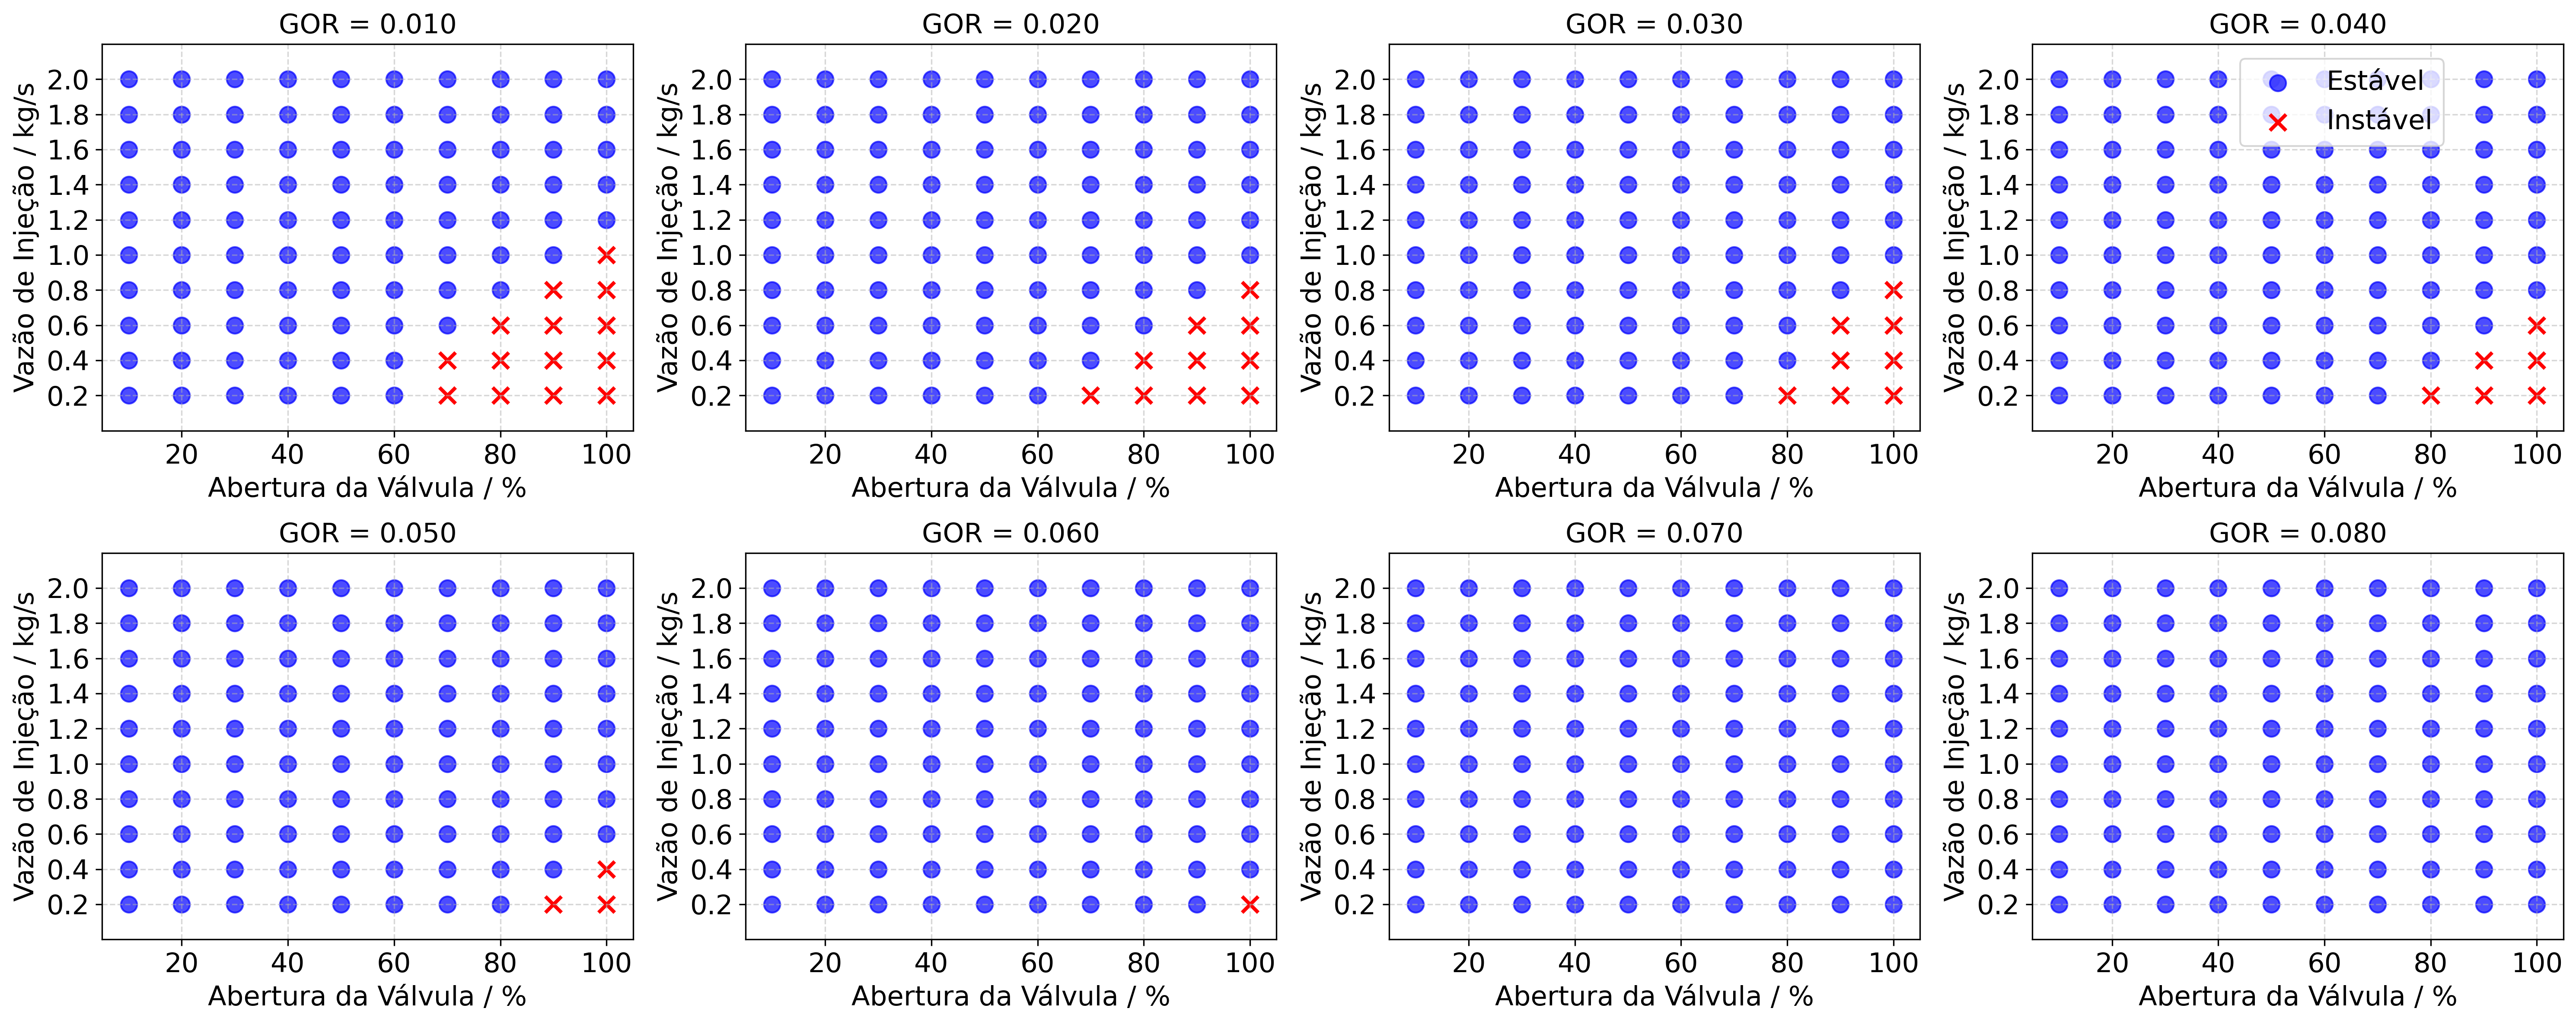

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar dados
df = pd.read_csv("resultados_EIK_CA.csv")

# Ajuste de estilo
point_size = 80
font_size = 15
tick_size = 15

# Valores de GOR
GOR_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
n_gor = len(GOR_values)

# Definir layout da grade de subplots
# Por exemplo, 2 linhas e 4 colunas para 8 gráficos
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8), dpi=300)
axes = axes.flatten()  # Achatar para facilitar a indexação

# Loop sobre cada valor de GOR
for idx, gor_val in enumerate(GOR_values):
    ax = axes[idx]
    
    # Filtrar dados para este GOR
    dfg = df[df['GOR'] == gor_val].copy()
    
    # Filtrar para mostrar apenas até 2 kg/s
    dfg = dfg[dfg['w_inj'] <= 2.0].copy()
    
    print(f"Para GOR={gor_val}:")
    print(f"  Total pontos (até 2 kg/s): {len(dfg)}")
    print(f"  Pontos com estado='1': {len(dfg[dfg['estado'] == 1])}")
    print(f"  Pontos com estado='0': {len(dfg[dfg['estado'] == 0])}")
    
    # Separar dados por estado
    df_est = dfg[dfg['estado'] == 1]
    df_ins = dfg[dfg['estado'] == 0]
    
    # Plotar pontos
    ax.scatter(df_est['u1']*100, df_est['w_inj'], 
               s=point_size, color='blue', alpha=0.7, label='Estável' if idx == 0 else "")
    ax.scatter(df_ins['u1']*100, df_ins['w_inj'], 
               s=point_size, color='red', marker='x', linewidths=2, label='Instável' if idx == 0 else "")
    
    # Configurar título e eixos
    ax.set_title(f"GOR = {gor_val:.3f}", fontsize=font_size)
    ax.set_xlabel("Abertura da Válvula / %", fontsize=font_size)
    ax.set_ylabel("Vazão de Injeção / kg/s", fontsize=font_size)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_yticks(np.arange(0.2, 2.1, 0.2))
    ax.set_ylim(0, 2.2)
    ax.set_xlim(5, 105)
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.grid(True, linestyle="--", alpha=0.5)

# Remover subplots extras se houver (caso n_gor < nrows*ncols)
for idx in range(n_gor, len(axes)):
    fig.delaxes(axes[idx])

# Adicionar legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=font_size, 
           bbox_to_anchor=(0.95, 0.95))

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar dados
df = pd.read_csv("resultados_EIK_CA.csv", sep=';', decimal=',')

# Ajuste de estilo - REDUZIDO
point_size = 20  # Reduzido de 80
font_size = 8  # Reduzido de 15
tick_size = 8   # Reduzido de 15

# Layout dos subplots
GOR_values = df['GOR'].unique()
n_gor = len(GOR_values)
ncols = 4
nrows = int(np.ceil(n_gor / ncols))

# FIGURA MENOR
fig, axs = plt.subplots(nrows, ncols, figsize=(8, 2), dpi=300)  # Reduzido de 18x6
axs = axs.flatten()

# Plot por GOR
for idx, gor_val in enumerate(GOR_values):
    dfg = df[df['GOR'] == gor_val]
    df_est = dfg[dfg['estado'] == 1]
    df_ins = dfg[dfg['estado'] == 0]

    ax = axs[idx]
    ax.scatter(df_est['u1']*100, df_est['w_inj'], 
               s=point_size, color='blue', alpha=0.7)
    ax.scatter(df_ins['u1']*100, df_ins['w_inj'], 
               s=point_size, color='red', marker='x', linewidths=1)  # linewidths reduzido

    ax.set_title(f"GOR = {gor_val:.3f}", fontsize=font_size)
    ax.set_xlabel("Abertura / %", fontsize=font_size)  # Título mais curto
    ax.set_ylabel("Injeção / kg/s", fontsize=font_size)  # Título mais curto
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_yticks(np.arange(0.2, 2.1, 0.4))  # Menos ticks no y
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlim(5, 105)

# Remove subplots vazios
for k in range(idx+1, len(axs)):
    fig.delaxes(axs[k])

# Ajustes finais - espaçamento reduzido
plt.tight_layout()
plt.subplots_adjust(top=0.9, right=0.95, wspace=0.3, hspace=0.3)  # Espaços menores
plt.show()

**Equação do plano que separa os regimes**

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import webbrowser
from pathlib import Path

# --- 1. Carregar e preparar os dados ---
df = pd.read_csv("resultados_EIK_CA.csv",  sep=';', decimal=',',)


df['u1_pct'] = df['u1'] * 100
df_estavel = df[df['estado'] == 1]
df_instavel = df[df['estado'] ==0]

ponto1_coords = [1.0, 0.4, 0.06]
ponto2_coords = [1.0, 1, 0.01]
ponto3_coords = [0.7, 0.4, 0.01]

# Convertendo para arrays numpy e ajustando a escala da abertura da válvula
p1 = np.array(ponto1_coords, dtype=float)
p1[0] *= 100  # Converte de fração para porcentagem (ex: 1.0 -> 100)

p2 = np.array(ponto2_coords, dtype=float)
p2[0] *= 100

p3 = np.array(ponto3_coords, dtype=float)
p3[0] *= 100

print("\n Pontos definidos manualmente para o plano:")
print(f"P1 (u1%, w_inj, GOR): {np.round(p1, 2)}")
print(f"P2 (u1%, w_inj, GOR): {np.round(p2, 2)}")
print(f"P3 (u1%, w_inj, GOR): {np.round(p3, 2)}")


# --- 3. Calcular a Equação do Plano (ax + by + cz = d) ---
# Vetores no plano
v1 = p2 - p1
v2 = p3 - p1

# Vetor normal ao plano (produto vetorial)
normal = np.cross(v1, v2)
a, b, c = normal

# Constante d da equação do plano
d = np.dot(normal, p1)


# --- 4. Preparar o Grid e Plotar o Plano ---
# Criar uma malha 2D para os eixos X (u1_pct) e Y (w_inj)
x_plane = np.linspace(df['u1_pct'].min(), df['u1_pct'].max(), 10)
y_plane = np.linspace(df['w_inj'].min(), df['w_inj'].max(), 10)
xx, yy = np.meshgrid(x_plane, y_plane)

# Calcular a coordenada Z (GOR) para cada ponto da malha usando a equação do plano
# z = (d - ax - by) / c
# Adicionado um pequeno valor a 'c' para evitar divisão por zero se o plano for vertical
zz = (d - a * xx - b * yy) / (c + 1e-9)


# --- 5. Criar a figura 3D com os pontos e o plano ---
fig = go.Figure()

# Adiciona os pontos ESTÁVEIS e INSTÁVEIS
fig.add_trace(go.Scatter3d(
    x=df_estavel['u1_pct'], y=df_estavel['w_inj'], z=df_estavel['GOR'],
    mode='markers', marker=dict(size=4, color='blue', opacity=0.6), name='Estável'
))
fig.add_trace(go.Scatter3d(
    x=df_instavel['u1_pct'], y=df_instavel['w_inj'], z=df_instavel['GOR'],
    mode='markers', marker=dict(size=4, color='red', symbol='x', opacity=0.8), name='Instável'
))

# Adiciona o PLANO DE SEPARAÇÃO definido pelos seus pontos
fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    colorscale='Greys',
    opacity=0.4,
    showscale=False,
    name='Plano Manual'
))


# --- 6. Customizar layout e salvar ---
# --- 6. Customizar layout e salvar ---
fig.update_layout(
    title='<b>Mapa de Estabilidade com Plano Manual</b>',
    title_font=dict(size=28),  # Aumenta o título
    scene=dict(
        xaxis_title='Abertura da Válvula / %',
        yaxis_title='Taxa de Injeção / kg/s',
        zaxis_title='GOR / kg/kg',
        # Fonte maior nos títulos dos eixos
        xaxis_title_font=dict(size=17),
        yaxis_title_font=dict(size=17),
        zaxis_title_font=dict(size=17),
        # Fonte maior nos ticks dos eixos
        xaxis_tickfont=dict(size=14),
        yaxis_tickfont=dict(size=14),
        zaxis_tickfont=dict(size=14),
        # Limita os eixos
        xaxis_range=[0, 100],
        yaxis_range=[df['w_inj'].min(), df['w_inj'].max()],
        zaxis_range=[df['GOR'].min(), df['GOR'].max()],
        aspectmode='cube'
    ),
    scene_camera=dict(eye=dict(x=1.8, y=-1.8, z=1.2)),
    margin=dict(l=0, r=0, b=0, t=60),
    legend=dict(
        x=0.01, y=0.98,
        font=dict(size=18)  # Fonte maior na legenda
    )
)


output_file = "mapa_estabilidade_3d_plano_manual.html"
fig.write_html(output_file)
print(f"\n Gráfico 3D com plano manual salvo como '{output_file}'")

webbrowser.open(f'file://{Path.cwd() / output_file}')
print(" Gráfico aberto no seu navegador!")

In [ ]:
# Multiplicamos 'a' por 100 para compensar a escala da porcentagem
a_ajustado = a * 100

print("\n Inequação Final (u1 de 0 a 1, w_inj kg/s, GOR kg/kg):")
print(f"{a_ajustado:.4f}*u1 + {b:.4f}*w_inj + {c:.4f}*GOR - ({d:.4f}) >= 0")

# Exemplo prático de como ficaria a conta:
print(f"\nExemplo: Para u1=0.8, w_inj=1.5, GOR=0.03")
valor = a_ajustado*0.8 + b*1.5 + c*0.03 - d
print(f"Resultado: {valor:.4f} ({'Normal' if valor >= 0 else 'CH'})")


📐 Inequação Final (u1 de 0 a 1, w_inj kg/s, GOR kg/kg):
-10.7689*u1 + 4.6149*w_inj + 76.9225*GOR - (-4.8461) >= 0

Exemplo: Para u1=0.8, w_inj=1.5, GOR=0.03
Resultado: 5.4610 (Estável)


**Poço Krishnamoorty**

In [3]:
    # Parametros
M = 0.028# Massa molar do gás [kg/mol]
Ta = 301 # Temperatura da região anular [K]
La = 1500  # Comprimento da região anular [m]
ro = 800# Densidade do óleo no reservatório [kg/m³]
Tw = 305 # Temperatura no tubo [K]
Lw = 1500  # Comprimento do tubo [m]
Lr = 500  # Distância do reservatório até o ponto de injeção [m]
  # Área da seção transversal abaixo do ponto injeção [m²]
 # Área da seção transversal acima do ponto injeção [m²]
Hw = 1500  # [m]  

Dw= 0.121
Dr =0.121
u1= 1# Exemplo de valor para u
#u1= 50**(u - 1) 

Dbh = 0.121
Da = 0.189
Hr = 500
Hbh = 500
Lbh = 500
Tr = 301
PI = 0.7e-5
Cpc = 2e-3 # [m²]
Civ =  1e-4   # [m²]
Cr = 2.6e-4  # [m²]
Crh = 10e-3
Pr = 15.5e6  # Pressão no reservatório longe da cabeça do poço [Pa]
Ps = 2e6 # Pressão no manifold [Pa]
#mi_m = 0.003
#mi_r = 0.003
vo = 1 / ro  # Volume específico do óleo  
g = 9.81  # Aceleração da gravidade [m/s²]
Riser_p_fric = 0.5
R = 8.314  # Constante dos gases [J/mol.K]
GOR =0.01
dp_t_fric = 1.0e5 #'atm';
dp_bh_fric = 5.0e4 #'atm';

Ha = 1000
# Cálculo das áreas
Aw = (ca.pi * (Dw ** 2)) / 4  # Área da seção transversal do poço [m²]
Aa = (ca.pi * (Da ** 2)) / 4 - (ca.pi * (Dw ** 2)) / 4  # Área da seção transversal do anel [m²]
Ar = (ca.pi * (Dr ** 2)) / 4  # Área da seção transversal abaixo do ponto de injeção [m²]
Va = La * Aa  # Volume da região anular [m³]versal abaixo do ponto de injeção [m²]
Abh = (ca.pi * (Dbh ** 2)) / 4
epsilon = 4.57e-5  # Rugosidade do tubo [m] (aço comercial)
mu_w = 0.001    

CasADi - 2026-03-14 09:35:48 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:515]


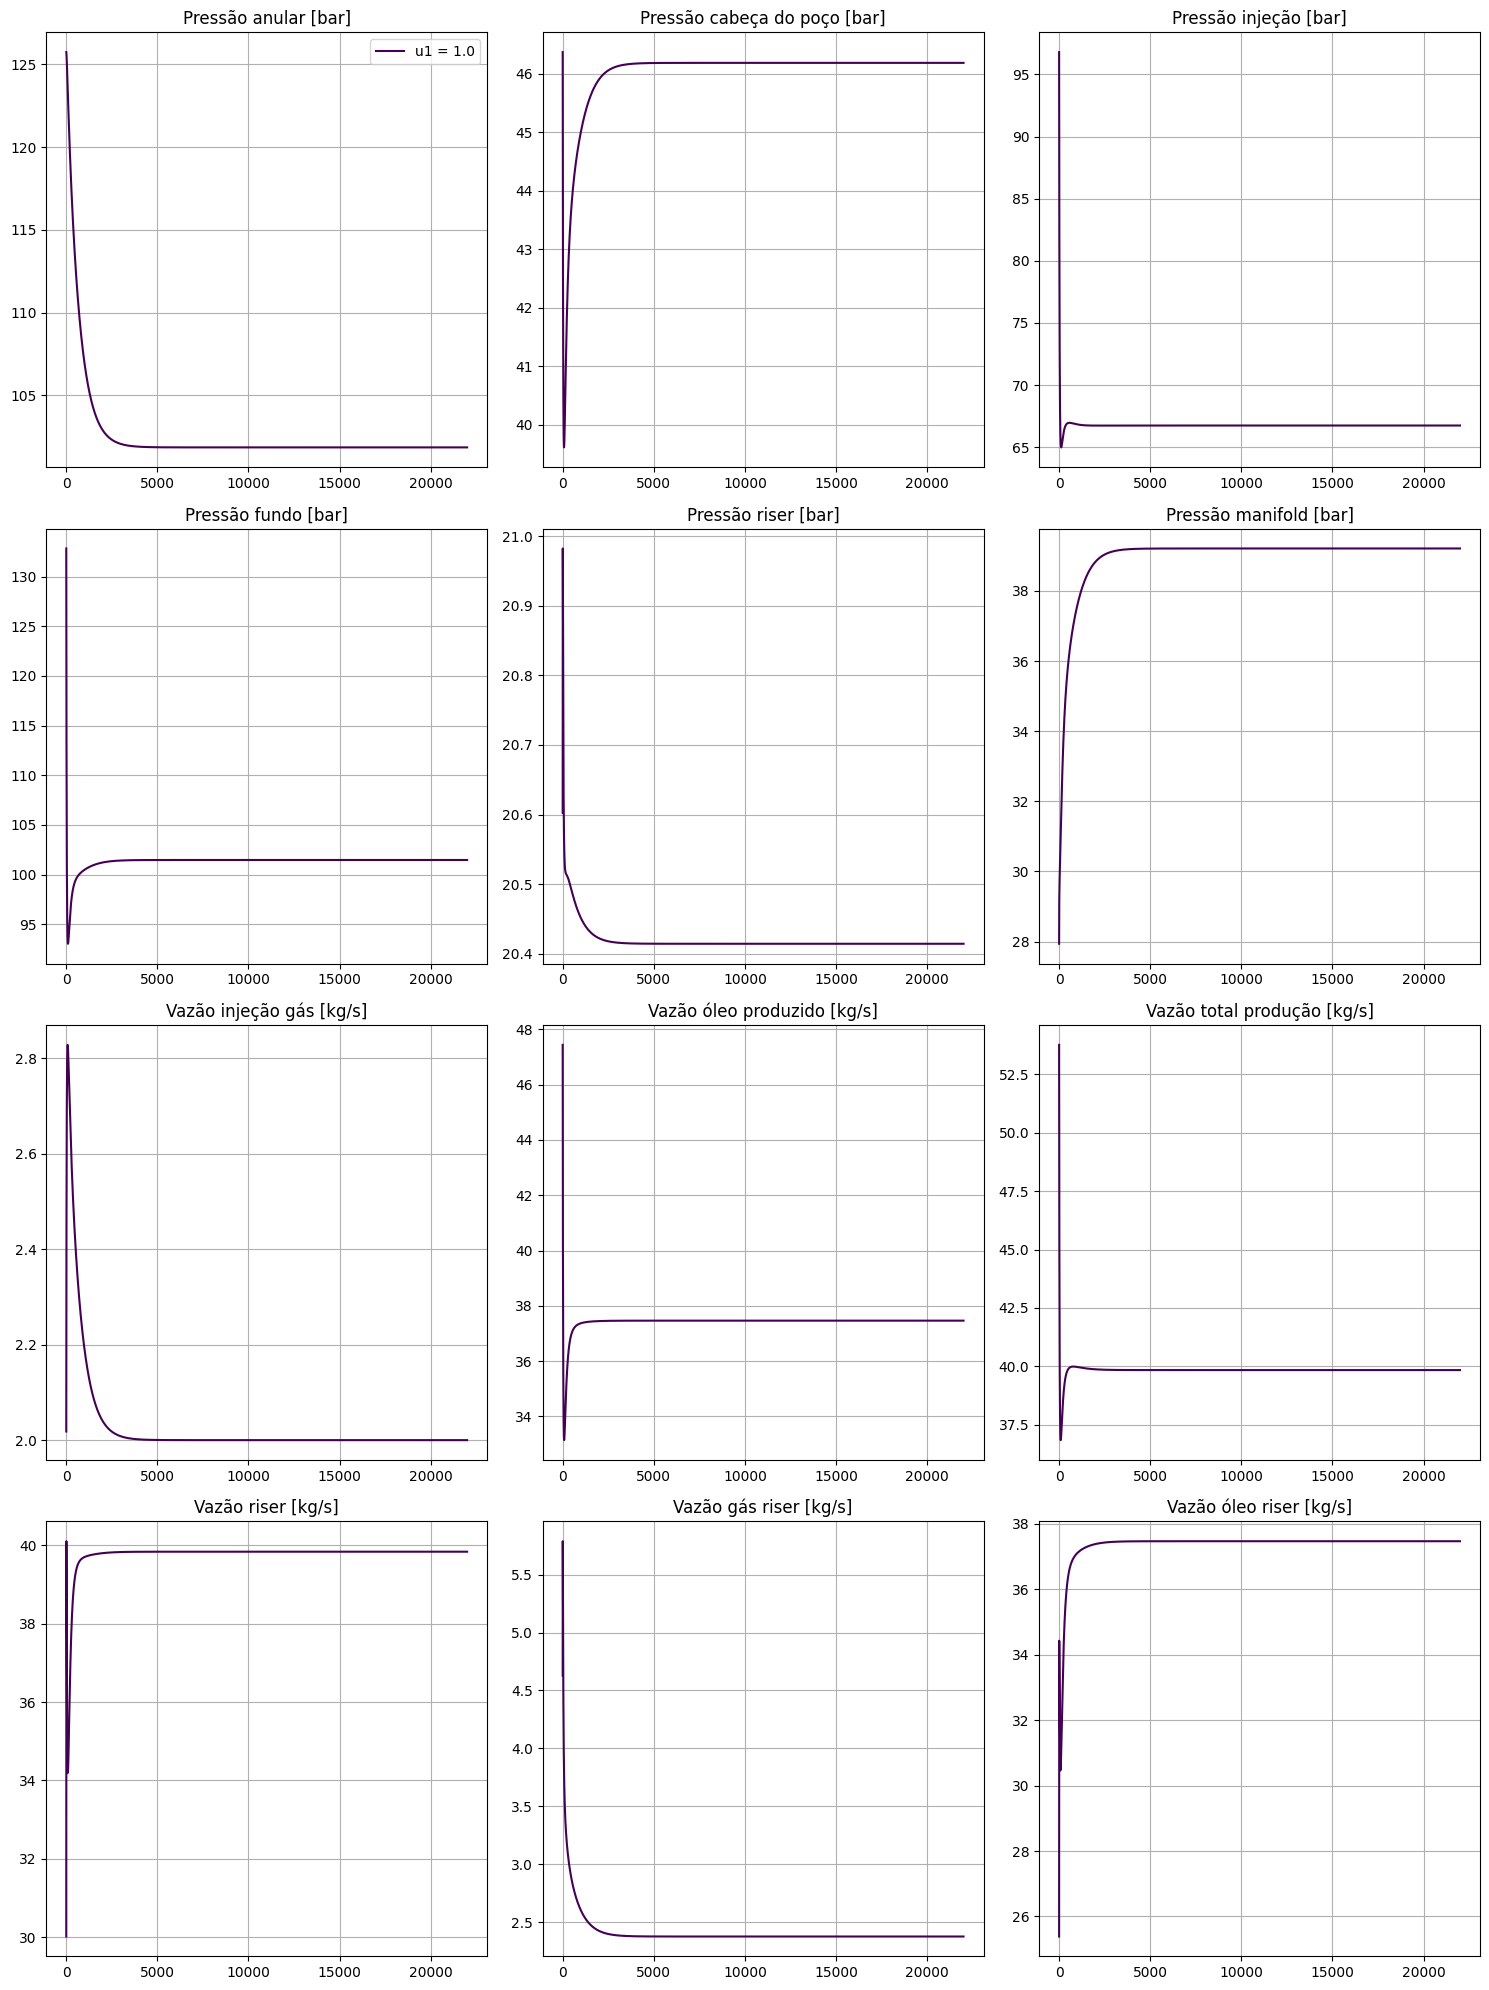

37.46423672311262


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca


def fun(t, x, par, u1, GOR):
    # States
    x1, x2, x3, x4, x5 = x[0], x[1], x[2], x[3], x[4]

    # Pressure Calculations
    Pai = ((R * Ta / (Va * M)) + ((g * La) / (La * Aa))) * x1
    Pwh = (R * Tw / M) * (x2 / (Lw * Aw + Lr * Ar - (vo * x3))) #- 1/2 * ((x2 + x3) * g * Hw / (Lw * Aw))
    ro_r = (x4 + x5) / (Lr * Ar + 1e-9)
    Prh = (Tr * R / M) * (x4 / (Lbh * Abh + 1e-9))
    Pm = Prh + (ro_r * g * Hbh)

    # Intermediate Calculations
    D = ca.sqrt(Aw * 4 / ca.pi)
    ro_w = (x2 + x3) / (Lw * Aw + 1e-9)
    y3 = ca.fmax(0, (Pwh - Pm))

    # Flow Rate Calculation
    wpc = Cpc * ca.sqrt(ro_w * y3 + 1e-9) * 50**(u1 - 1)
    veloc = wpc / (ro_w * Aw + 1e-9)
    
    # Viscosidade da mistura
    mi_m = (x3 / (x2 + x3 + 1e-9)) * 0.002 + (x2 / (x2 + x3 + 1e-9)) * 0.007e-3
    
    # Número de Reynolds
    Re = ca.fmax(1, ro_w * veloc * D / (mi_m + 1e-9))
    
    # Fator de atrito
    fa = ca.if_else(Re < 50000, 
                    0.316 * Re**-0.25, 
                    0.184 * Re**-0.20)
    
    # Perda de pressão
    gradf = fa * ro_w * veloc**2 / (2 * D + 1e-9)
    P_fric_t = Lw * gradf
    P_fric_bh = Hbh * gradf

    # Pressões
    Pwi = Pwh + g / (Lw * Aw + 1e-9) * (x3 + x2) + P_fric_t
    Pwb = Pwi + (ro_w * g * Hr) + P_fric_bh

    # Densities
    ro_a = (M * Pai) / (R * Ta + 1e-9)

    # Flow Rates
    y4 = ca.fmax(0, (Prh - Ps))
    y1 = ca.fmax(0, (Pai - Pwi))
    y2 = ca.fmax(0, (Pr - Pwb))
    
    wiv = Civ * ca.sqrt(ro_a * y1 + 1e-9)
    wpg = (x2 / (x2 + x3 + 1e-9)) * wpc
    wpo = (x3 / (x2 + x3 + 1e-9)) * wpc
    wro = PI * (Pr - Pwb)
    wrg = GOR * wro
    wrh = Crh * ca.sqrt(ro_r * y4 + 1e-9)
    wtg = (x4 / (x4 + x5 + 1e-9)) * wrh
    wto = (x5 / (x4 + x5 + 1e-9)) * wrh

    # Derivatives
    dx1 = par - wiv
    dx2 = wiv + wrg - wpg
    dx3 = wro - wpo
    dx4 = wpg - wtg
    dx5 = wpo - wto

    return ca.vertcat(dx1, dx2, dx3, dx4, dx5)


def modelo(x, par, u1, GOR):
    x1, x2, x3, x4, x5 = x[0], x[1], x[2], x[3], x[4]

    # Pressure Calculations
    Pai = ((R * Ta / (Va * M)) + ((g * La) / (La * Aa))) * x1
    Pwh = (R * Tw / M) * (x2 / (Lw * Aw + Lr * Ar - (vo * x3)))# - 1/2 * ((x2 + x3) * g * Hw / (Lw * Aw))
    ro_r = (x4 + x5) / (Lr * Ar + 1e-9)
    Prh = (Tr * R / M) * (x4 / (Lbh * Abh + 1e-9))
    Pm = Prh + (ro_r * g * Hbh)

    # Intermediate Calculations
    D = ca.sqrt(Aw * 4 / ca.pi)
    ro_w = (x2 + x3) / (Lw * Aw)
    y3 = ca.fmax(0, (Pwh - Pm))

    # Flow Rate Calculation
    wpc = Cpc * ca.sqrt(ro_w * y3 ) * 50**(u1 - 1)
    veloc = wpc / (ro_w * Aw )
    
    # Viscosidade da mistura
    mi_m = (x3 / (x2 + x3 )) * 0.002 + (x2 / (x2 + x3)) * 0.007e-3
    
    # Número de Reynolds
    Re = ca.fmax(1, ro_w * veloc * D / (mi_m ))
    
    # Fator de atrito
    fa = ca.if_else(Re < 50000, 
                    0.316 * Re**-0.25, 
                    0.184 * Re**-0.20)
    
    # Perda de pressão
    gradf = fa * ro_w * veloc**2 / (2 * D + 1e-9)
    P_fric_t = Lw * gradf
    P_fric_bh = Hbh * gradf

    # Pressões
    Pwi = Pwh + g / (Lw * Aw + 1e-9) * (x3 + x2) + P_fric_t
    Pwb = Pwi + (ro_w * g * Hr) + P_fric_bh

    # Densities
    ro_a = (M * Pai) / (R * Ta + 1e-9)

    # Flow Rates
    y4 = ca.fmax(0, (Prh - Ps))
    y1 = ca.fmax(0, (Pai - Pwi))
    y2 = ca.fmax(0, (Pr - Pwb))
    
    wiv = Civ * ca.sqrt(ro_a * y1 + 1e-9)
    wpg = (x2 / (x2 + x3 + 1e-9)) * wpc
    wpo = (x3 / (x2 + x3 + 1e-9)) * wpc
    wro = PI * (Pr - Pwb)
    wrg = GOR * wro
    wrh = Crh * ca.sqrt(ro_r * y4 + 1e-9)
    wtg = (x4 / (x4 + x5 + 1e-9)) * wrh
    wto = (x5 / (x4 + x5 + 1e-9)) * wrh

    return {
        'Pai': Pai,
        'Pwh': Pwh,
        'Pwi': Pwi,
        'Pwb': Pwb,
        'wiv': wiv,
        'wro': wro,
        'wpc': wpc,
        'wpg': wpg,
        'wpo': wpo,
        'wrg': wrg,
        'wrh': wrh,
        'wtg': wtg,
        'wto': wto,
        "ro_w": ro_w,
        "ro_a": ro_a,
        "ro_r": ro_r,
        "Prh": Prh,
        "Pm": Pm
    }

# ==============================================================================
# Configuração da simulação
# ==============================================================================
w_inj = 2.0
GOR_val = 0.01
u1_values = [1.0]
y0 = [3000, 800, 6000, 130, 700] # 5 estados agora

t0 = 0
tf = 22000
dt = 1
t = np.arange(t0, tf, dt)


x_sym = ca.SX.sym('x', 5)  # 5 estados
par_sym = ca.SX.sym('par')
u1_sym = ca.SX.sym('u1')
GOR_sym = ca.SX.sym('GOR')

dx_sym = fun(0, x_sym, par_sym, u1_sym, GOR_sym)  # Agora com 5 argumentos
dae = {'x': x_sym, 'p': ca.vertcat(par_sym, u1_sym, GOR_sym), 'ode': dx_sym}
opts = {'tf': dt}
integrator = ca.integrator('integrator', 'rk', dae, opts)

# ==============================================================================
# Simulação
# ==============================================================================
plt.figure(figsize=(15, 20))
colors = plt.cm.viridis(np.linspace(0, 1, len(u1_values)))

for i, u1 in enumerate(u1_values):
    x_current = np.array(y0)
    results = {
        'Pai': [], 'Pwh': [], 'Pwi': [], 'Pwb': [],
        'wiv': [], 'wro': [], 'wpc': [], 'wpg': [], 
        'wpo': [], 'wrg': [], 'wrh': [], 'wtg': [], 'wto': [],
        'Prh': [], 'Pm': []
    }
    
    for ti in t:
        res = integrator(x0=x_current, p=[w_inj, u1, GOR_val])
        x_next = res['xf'].full().flatten()
        model_output = modelo(x_next, w_inj, u1, GOR_val)
        
        for key in results:
            if key in model_output:
                results[key].append(float(model_output[key]))
        
        x_current = x_next
    
    for key in results:
        results[key] = np.array(results[key])
    
    # Plotagens (adaptadas)
    plt.subplot(4, 3, 1)
    plt.plot(t, results['Pai']/1e5, color=colors[i], label=f'u1 = {u1}')
    plt.title("Pressão anular [bar]")
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 3, 2)
    plt.plot(t, results['Pwh']/1e5, color=colors[i])
    plt.title("Pressão cabeça do poço [bar]")
    plt.grid()
    
    plt.subplot(4, 3, 3)
    plt.plot(t, results['Pwi']/1e5, color=colors[i])
    plt.title("Pressão injeção [bar]")
    plt.grid()
    
    plt.subplot(4, 3, 4)
    plt.plot(t, results['Pwb']/1e5, color=colors[i])
    plt.title("Pressão fundo [bar]")
    plt.grid()
    
    plt.subplot(4, 3, 5)
    plt.plot(t, results['Prh']/1e5, color=colors[i])
    plt.title("Pressão riser [bar]")
    plt.grid()
    
    plt.subplot(4, 3, 6)
    plt.plot(t, results['Pm']/1e5, color=colors[i])
    plt.title("Pressão manifold [bar]")
    plt.grid()
    
    plt.subplot(4, 3, 7)
    plt.plot(t, results['wiv'], color=colors[i])
    plt.title("Vazão injeção gás [kg/s]")
    plt.grid()
    
    plt.subplot(4, 3, 8)
    plt.plot(t, results['wpo'], color=colors[i])
    plt.title("Vazão óleo produzido [kg/s]")
    plt.grid()
    
    plt.subplot(4, 3, 9)
    plt.plot(t, results['wpc'], color=colors[i])
    plt.title("Vazão total produção [kg/s]")
    plt.grid()
    
    plt.subplot(4, 3, 10)
    plt.plot(t, results['wrh'], color=colors[i])
    plt.title("Vazão riser [kg/s]")
    plt.grid()
    
    plt.subplot(4, 3, 11)
    plt.plot(t, results['wtg'], color=colors[i])
    plt.title("Vazão gás riser [kg/s]")
    plt.grid()
    
    plt.subplot(4, 3, 12)
    plt.plot(t, results['wto'], color=colors[i])
    plt.title("Vazão óleo riser [kg/s]")
    plt.grid()

plt.tight_layout()
plt.show()



print(results["wpo"][-1])

**Simulação mapa para Krishinamoorty**

In [5]:
import numpy as np
import pandas as pd
import casadi as ca

u1_values = np.linspace(0.1, 1, 10)
w_inj_values = np.linspace(0.2, 2, 10)
y0 = [2100, 400, 5700, 100, 100]  # 5 estados: [x1, x2, x3, x4, x5]
GOR_values = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08]
t0, dt = 0, 1
tf_max = 18000

# Parâmetros de classificação*
tolerance = 1e-4
passos_estaveis = 50


x_sym = ca.SX.sym('x', 5)  # 5 estados
par_sym = ca.SX.sym('par')
u1_sym = ca.SX.sym('u1')
GOR_sym = ca.SX.sym('GOR')

dx_sym = fun(0, x_sym, par_sym, u1_sym, GOR_sym)  # fun com 5 argumentos
dae = {'x': x_sym, 'p': ca.vertcat(par_sym, u1_sym, GOR_sym), 'ode': dx_sym}
opts = {'tf': dt}
integrator = ca.integrator('integrator', 'rk', dae, opts)

def run_simulation(w_inj, u1, gor_val):
    x_current = np.array(y0)
    t = np.arange(t0, tf_max, dt)
    
    results = []
    contador = 0
    stable_found = False

    for i, ti in enumerate(t):
        res = integrator(x0=x_current, p=[w_inj, u1, gor_val])
        x_next = res['xf'].full().flatten()
        out = modelo(x_next, w_inj, u1, gor_val)  # modelo com 4 argumentos
        
        output_step = out.copy()
        output_step['x1'] = float(x_next[0])
        output_step['x2'] = float(x_next[1])
        output_step['x3'] = float(x_next[2])
        output_step['x4'] = float(x_next[3])  # massa de gás no riser
        output_step['x5'] = float(x_next[4])  # massa de óleo no riser
        results.append(output_step)
        
        if i > 0:
            delta = abs(x_next[0] - x_current[0])  # continua usando x1 como referência
            if delta <= tolerance:
                contador += 1
            else:
                contador = 0

            if contador >= passos_estaveis:
                stable_found = True
                break

        x_current = x_next

    if u1 <= 0.2:
        estado = '1'
    else:
        estado = '1' if stable_found else '0'

    if stable_found:
        resultado = results[-1].copy()
        resultado['estado'] = estado
        return resultado
    else:
        meio = len(results) // 2
        if len(results) > 0:
            keys = results[0].keys()
            media = {k: np.mean([d[k] for d in results[meio:]]) for k in keys}
        else:
            media = {}
        media['estado'] = estado
        return media


all_results = []
for gor in GOR_values:
    for u1 in u1_values:
        for w_inj in w_inj_values:
            res = run_simulation(w_inj, u1, gor)
            res['GOR'] = gor
            res['u1'] = u1
            res['w_inj'] = w_inj
            all_results.append(res)

df_final = pd.DataFrame(all_results)

df_final.to_csv("resultados_Krish_CA.csv",sep=';', decimal=',', index=False)


**Grafico mapa Krishinamoorty**

Para GOR=0.01:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 93
  Pontos com estado='0': 7


C:\Users\denil\AppData\Local\Temp\ipykernel_9272\2032694123.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


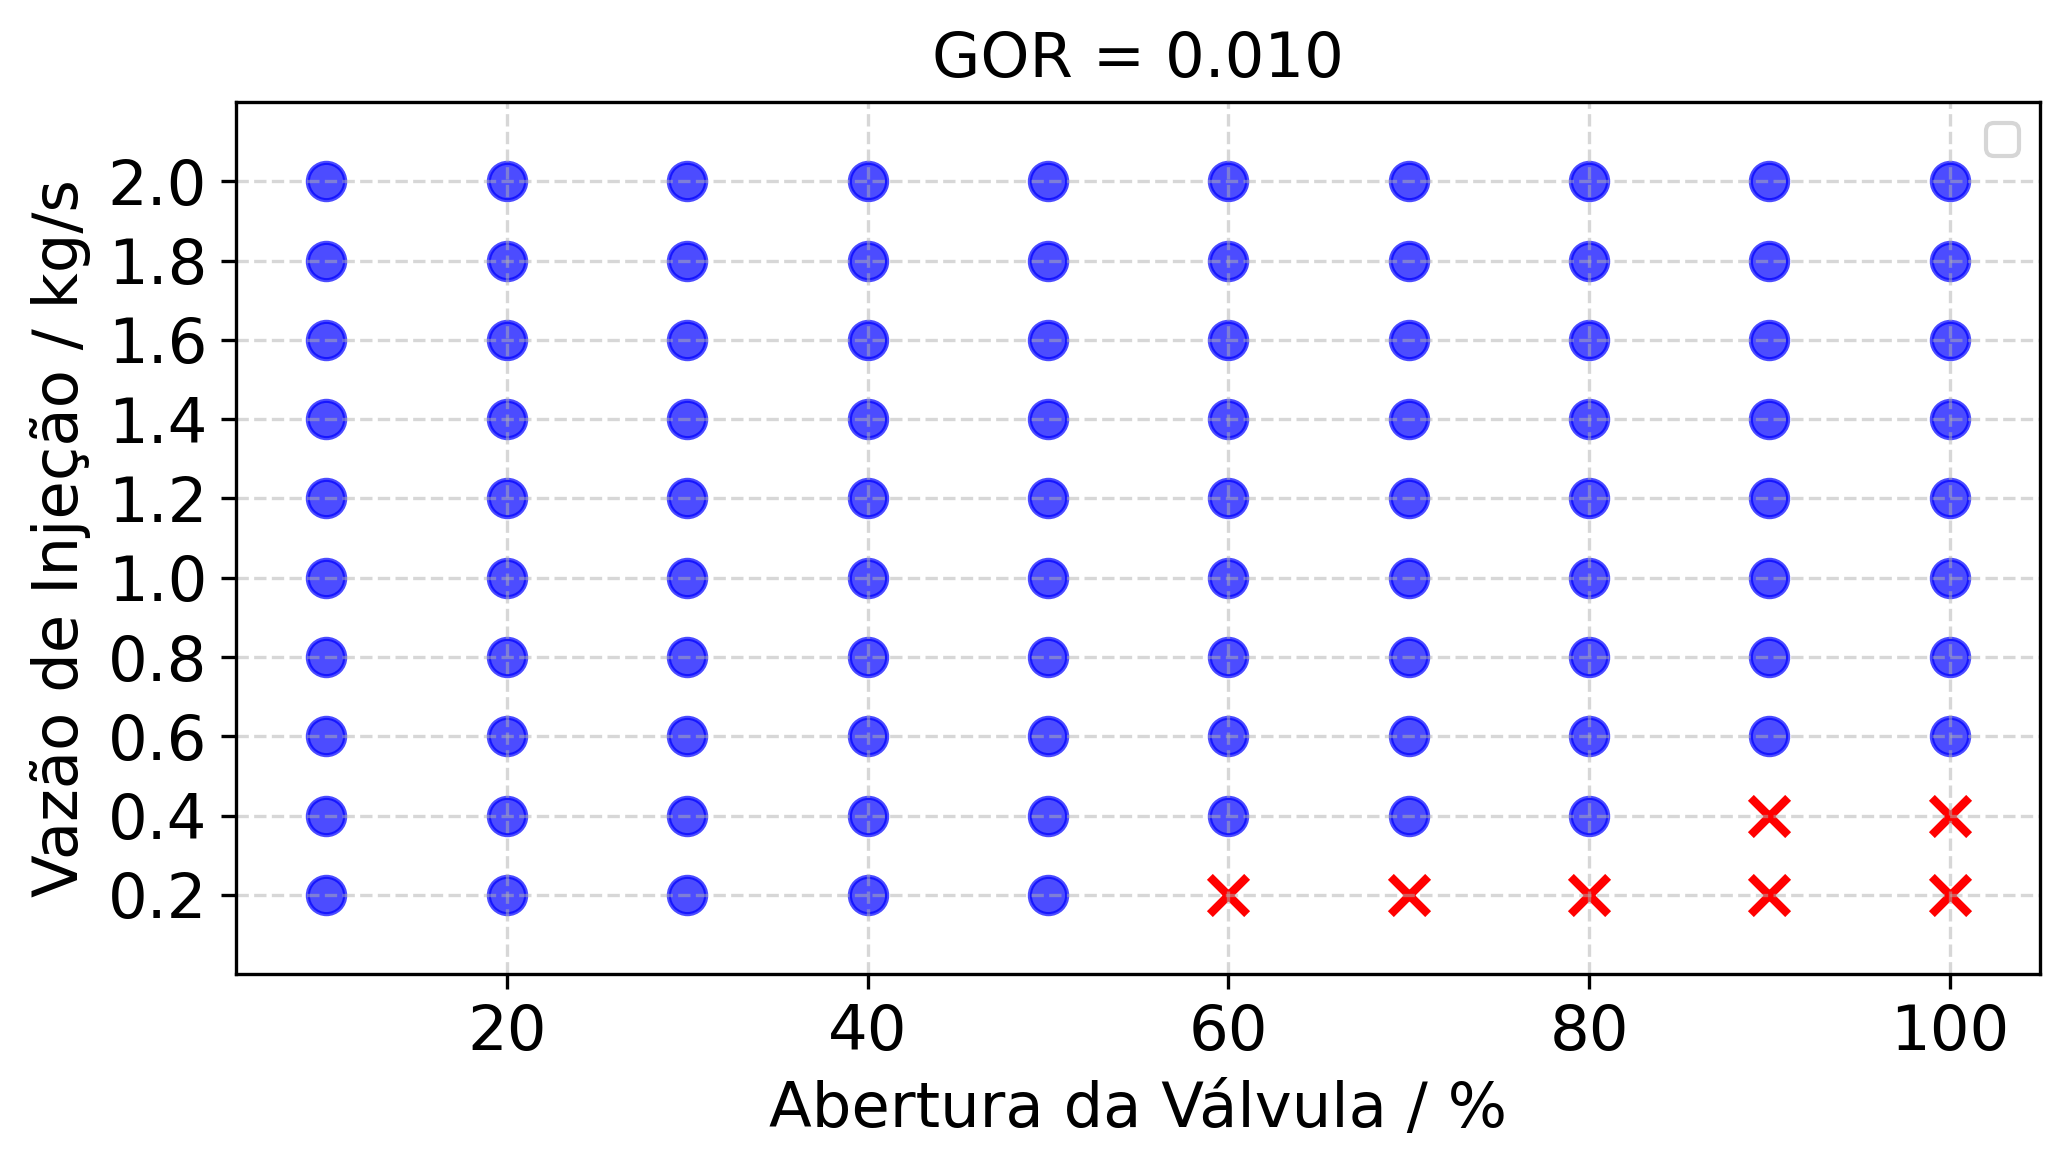

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar dados
#df = pd.read_csv("resultados_completos.csv")
df = pd.read_csv("resultados_Krish_CA.csv",sep=';', decimal=',')

# Ajuste de estilo
point_size = 80
font_size = 15
tick_size = 15

# Layout dos subplots
GOR_values = df['GOR'].unique()
n_gor = len(GOR_values)
ncols = 1  # Só 1 GOR, então 1 coluna
nrows = 1

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=300)

# Plot
gor_val = GOR_values[0]
dfg = df[df['GOR'] == gor_val]

# FILTRAR PARA MOSTRAR APENAS ATÉ 2 kg/s
dfg = dfg[dfg['w_inj'] <= 2.0].copy()

print(f"Para GOR={gor_val}:")
print(f"  Total pontos (até 2 kg/s): {len(dfg)}")
print(f"  Pontos com estado='1': {len(dfg[dfg['estado'] == 1])}")
print(f"  Pontos com estado='0': {len(dfg[dfg['estado'] == 0])}")

df_est = dfg[dfg['estado'] == 1]
df_ins = dfg[dfg['estado'] == 0]

ax.scatter(df_est['u1']*100, df_est['w_inj'], 
           s=point_size, color='blue', alpha=0.7)
ax.scatter(df_ins['u1']*100, df_ins['w_inj'], 
           s=point_size, color='red', marker='x', linewidths=2)

ax.set_title(f"GOR = {gor_val:.3f}", fontsize=font_size)
ax.set_xlabel("Abertura da Válvula / %", fontsize=font_size)
ax.set_ylabel("Vazão de Injeção / kg/s", fontsize=font_size)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_yticks(np.arange(0.2, 2.1, 0.2))  # Agora vai só até 2.0
ax.set_ylim(0, 2.2)  # Define limite do eixo y até 2.2 kg/s
ax.tick_params(axis='both', labelsize=tick_size)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(5, 105)
ax.legend()

plt.tight_layout()
plt.show()

Para GOR=0.01:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 93
  Pontos com estado='0': 7
Para GOR=0.02:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 98
  Pontos com estado='0': 2
Para GOR=0.03:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 100
  Pontos com estado='0': 0
Para GOR=0.04:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 100
  Pontos com estado='0': 0
Para GOR=0.05:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 100
  Pontos com estado='0': 0
Para GOR=0.06:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 100
  Pontos com estado='0': 0
Para GOR=0.07:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 100
  Pontos com estado='0': 0
Para GOR=0.08:
  Total pontos (até 2 kg/s): 100
  Pontos com estado='1': 100
  Pontos com estado='0': 0


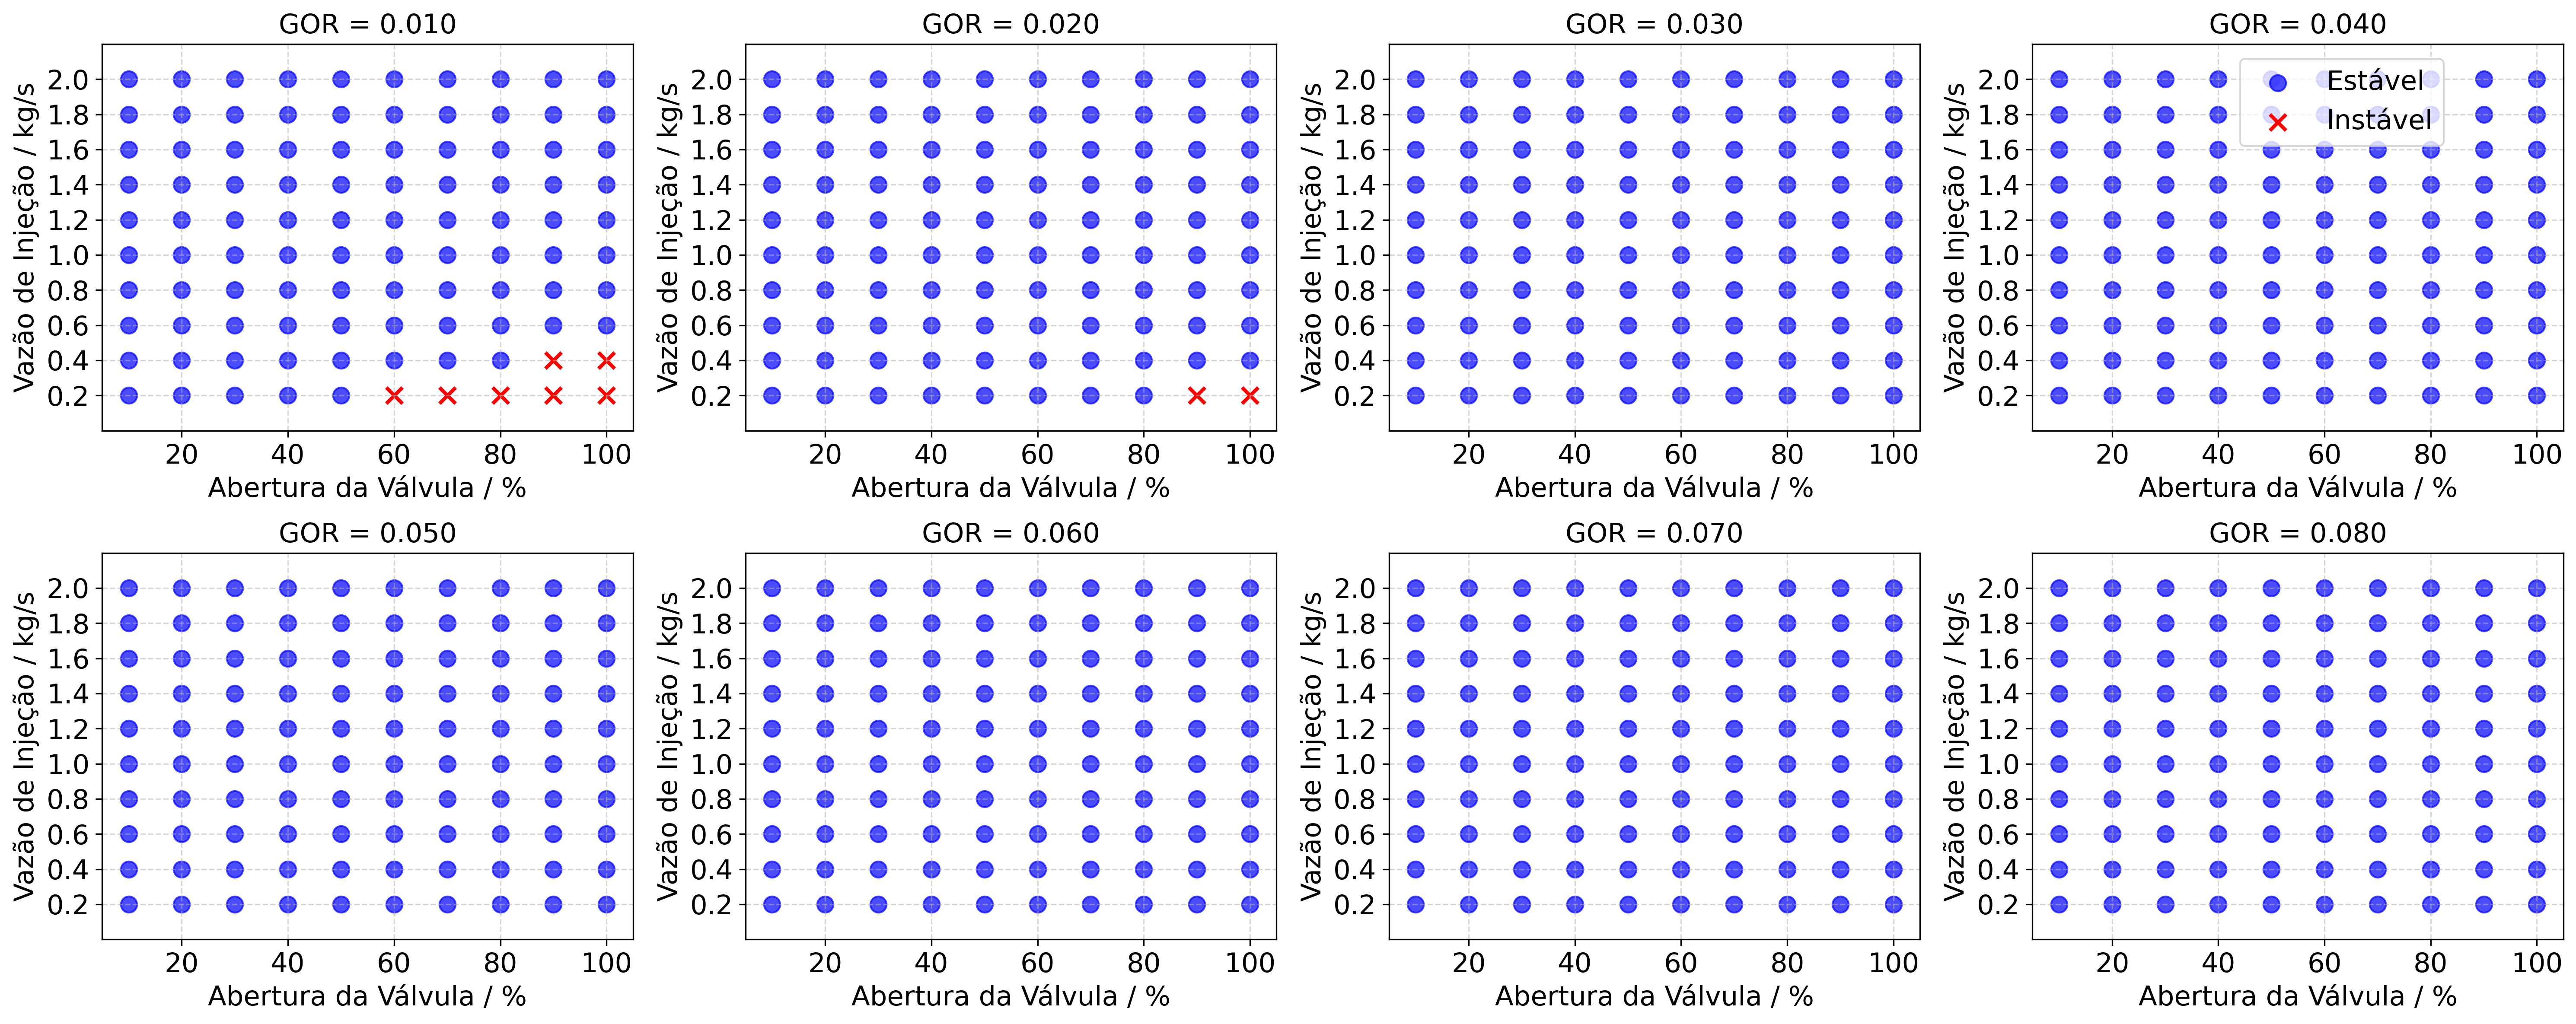

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar dados
df = pd.read_csv("resultados_krish_CA.csv",sep=';', decimal=',')

# Ajuste de estilo
point_size = 80
font_size = 15
tick_size = 15

# Valores de GOR
GOR_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
n_gor = len(GOR_values)

# Definir layout da grade de subplots
# Por exemplo, 2 linhas e 4 colunas para 8 gráficos
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8), dpi=300)
axes = axes.flatten()  # Achatar para facilitar a indexação

# Loop sobre cada valor de GOR
for idx, gor_val in enumerate(GOR_values):
    ax = axes[idx]
    
    # Filtrar dados para este GOR
    dfg = df[df['GOR'] == gor_val].copy()
    
    # Filtrar para mostrar apenas até 2 kg/s
    dfg = dfg[dfg['w_inj'] <= 2.0].copy()
    
    print(f"Para GOR={gor_val}:")
    print(f"  Total pontos (até 2 kg/s): {len(dfg)}")
    print(f"  Pontos com estado='1': {len(dfg[dfg['estado'] == 1])}")
    print(f"  Pontos com estado='0': {len(dfg[dfg['estado'] == 0])}")
    
    # Separar dados por estado
    df_est = dfg[dfg['estado'] == 1]
    df_ins = dfg[dfg['estado'] == 0]
    
    # Plotar pontos
    ax.scatter(df_est['u1']*100, df_est['w_inj'], 
               s=point_size, color='blue', alpha=0.7, label='Estável' if idx == 0 else "")
    ax.scatter(df_ins['u1']*100, df_ins['w_inj'], 
               s=point_size, color='red', marker='x', linewidths=2, label='Instável' if idx == 0 else "")
    
    # Configurar título e eixos
    ax.set_title(f"GOR = {gor_val:.3f}", fontsize=font_size)
    ax.set_xlabel("Abertura da Válvula / %", fontsize=font_size)
    ax.set_ylabel("Vazão de Injeção / kg/s", fontsize=font_size)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_yticks(np.arange(0.2, 2.1, 0.2))
    ax.set_ylim(0, 2.2)
    ax.set_xlim(5, 105)
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.grid(True, linestyle="--", alpha=0.5)

# Remover subplots extras se houver (caso n_gor < nrows*ncols)
for idx in range(n_gor, len(axes)):
    fig.delaxes(axes[idx])

# Adicionar legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=font_size, 
           bbox_to_anchor=(0.95, 0.95))

plt.tight_layout()
plt.show()

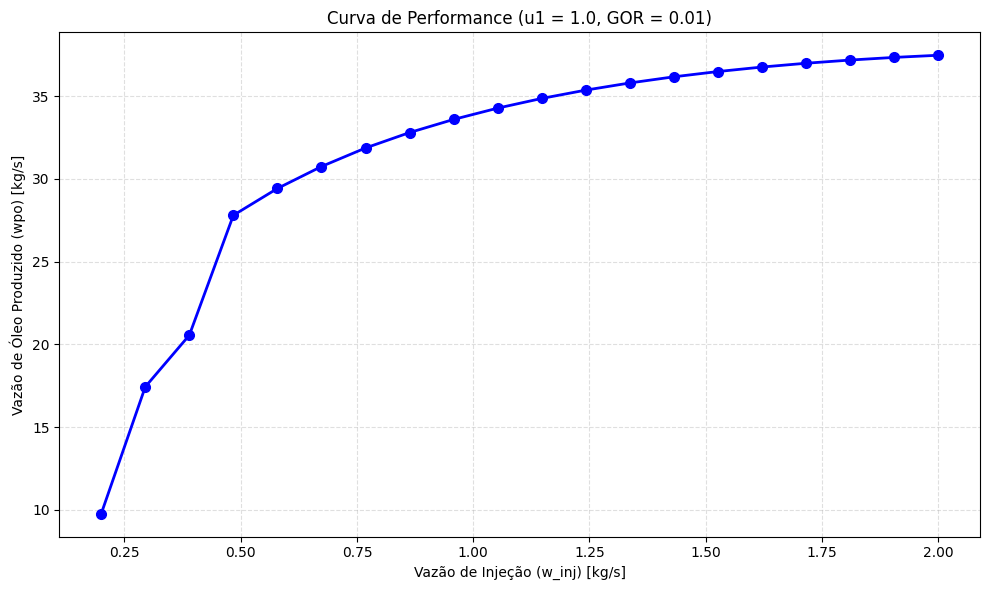

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("resultados_Krish_CA.csv")


u1_fixo = 1.0
GOR_fixo = 0.01

df_filtrado = df[(df['u1'] == u1_fixo) & (df['GOR'] == GOR_fixo)]

# Ordenar para linha contínua
df_filtrado = df_filtrado.sort_values('w_inj')

# ===============================
# Plotar gráfico
# ===============================
plt.figure(figsize=(10,6))

plt.plot(df_filtrado['w_inj'], df_filtrado['wpo'],
         'bo-', linewidth=2, markersize=7)

plt.xlabel('Vazão de Injeção (w_inj) [kg/s]')
plt.ylabel('Vazão de Óleo Produzido (wpo) [kg/s]')
plt.title(f'Curva de Performance (u1 = {u1_fixo}, GOR = {GOR_fixo})')

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#print(f"{row['w_inj']:<8.1f} {row['wpo']:<12.4f} {estado:<8}")

In [ ]:
import numpy as np
import pandas as pd
import casadi as ca

u1_values = np.linspace(0.1, 1, 10)
w_inj_values = np.linspace(0.2, 8, 40)
y0 = [2100, 400, 5700, 100, 100]  # 5 estados: [x1, x2, x3, x4, x5]
GOR_values = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08]
t0, dt = 0, 1
tf_max = 18000

# Parâmetros de classificação
tolerance = 1e-4
passos_estaveis = 50


x_sym = ca.SX.sym('x', 5)  # 5 estados
par_sym = ca.SX.sym('par')
u1_sym = ca.SX.sym('u1')
GOR_sym = ca.SX.sym('GOR')

dx_sym = fun(0, x_sym, par_sym, u1_sym, GOR_sym)  # fun com 5 argumentos
dae = {'x': x_sym, 'p': ca.vertcat(par_sym, u1_sym, GOR_sym), 'ode': dx_sym}
opts = {'tf': dt}
integrator = ca.integrator('integrator', 'rk', dae, opts)

def run_simulation(w_inj, u1, gor_val):
    x_current = np.array(y0)
    t = np.arange(t0, tf_max, dt)
    
    results = []
    contador = 0
    stable_found = False

    for i, ti in enumerate(t):
        res = integrator(x0=x_current, p=[w_inj, u1, gor_val])
        x_next = res['xf'].full().flatten()
        out = modelo(x_next, w_inj, u1, gor_val)  # modelo com 4 argumentos
        
        output_step = out.copy()
        output_step['x1'] = float(x_next[0])
        output_step['x2'] = float(x_next[1])
        output_step['x3'] = float(x_next[2])
        output_step['x4'] = float(x_next[3])  # massa de gás no riser
        output_step['x5'] = float(x_next[4])  # massa de óleo no riser
        results.append(output_step)
        
        if i > 0:
            delta = abs(x_next[0] - x_current[0])  # continua usando x1 como referência
            if delta <= tolerance:
                contador += 1
            else:
                contador = 0

            if contador >= passos_estaveis:
                stable_found = True
                break

        x_current = x_next

    if u1 <= 0.2:
        estado = '1'
    else:
        estado = '1' if stable_found else '0'

    if stable_found:
        resultado = results[-1].copy()
        resultado['estado'] = estado
        return resultado
    else:
        meio = len(results) // 2
        if len(results) > 0:
            keys = results[0].keys()
            media = {k: np.mean([d[k] for d in results[meio:]]) for k in keys}
        else:
            media = {}
        media['estado'] = estado
        return media


all_results = []
for gor in GOR_values:
    for u1 in u1_values:
        for w_inj in w_inj_values:
            res = run_simulation(w_inj, u1, gor)
            res['GOR'] = gor
            res['u1'] = u1
            res['w_inj'] = w_inj
            all_results.append(res)

df_final = pd.DataFrame(all_results)
df_final.to_csv("resultados_Krish_CA_8kgs.csv",  sep=';', decimal=',')

**Equação do plano que separa os regimes**

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import webbrowser
from pathlib import Path

# --- 1. Carregar e preparar os dados ---
df = pd.read_csv("resultados_Krish_CA.csv",  sep=';', decimal=',',)


df['u1_pct'] = df['u1'] * 100
df_estavel = df[df['estado'] == 1]
df_instavel = df[df['estado'] ==0]

ponto1_coords = [0.9, 0.2, 0.02]
ponto2_coords = [1, 0.4, 0.01]
ponto3_coords = [0.6, 0.2, 0.01]

# Convertendo para arrays numpy e ajustando a escala da abertura da válvula
p1 = np.array(ponto1_coords, dtype=float)
p1[0] *= 100  # Converte de fração para porcentagem (ex: 1.0 -> 100)

p2 = np.array(ponto2_coords, dtype=float)
p2[0] *= 100

p3 = np.array(ponto3_coords, dtype=float)
p3[0] *= 100

print("\n Pontos definidos manualmente para o plano:")
print(f"P1 (u1%, w_inj, GOR): {np.round(p1, 2)}")
print(f"P2 (u1%, w_inj, GOR): {np.round(p2, 2)}")
print(f"P3 (u1%, w_inj, GOR): {np.round(p3, 2)}")


# --- 3. Calcular a Equação do Plano (ax + by + cz = d) ---
# Vetores no plano
v1 = p2 - p1
v2 = p3 - p1

# Vetor normal ao plano (produto vetorial)
normal = np.cross(v1, v2)
a, b, c = normal

# Constante d da equação do plano
d = np.dot(normal, p1)


# --- 4. Preparar o Grid e Plotar o Plano ---
# Criar uma malha 2D para os eixos X (u1_pct) e Y (w_inj)
x_plane = np.linspace(df['u1_pct'].min(), df['u1_pct'].max(), 10)
y_plane = np.linspace(df['w_inj'].min(), df['w_inj'].max(), 10)
xx, yy = np.meshgrid(x_plane, y_plane)

# Calcular a coordenada Z (GOR) para cada ponto da malha usando a equação do plano
# z = (d - ax - by) / c
# Adicionado um pequeno valor a 'c' para evitar divisão por zero se o plano for vertical
zz = (d - a * xx - b * yy) / (c + 1e-9)


# --- 5. Criar a figura 3D com os pontos e o plano ---
fig = go.Figure()

# Adiciona os pontos ESTÁVEIS e INSTÁVEIS
fig.add_trace(go.Scatter3d(
    x=df_estavel['u1_pct'], y=df_estavel['w_inj'], z=df_estavel['GOR'],
    mode='markers', marker=dict(size=4, color='blue', opacity=0.6), name='Estável'
))
fig.add_trace(go.Scatter3d(
    x=df_instavel['u1_pct'], y=df_instavel['w_inj'], z=df_instavel['GOR'],
    mode='markers', marker=dict(size=4, color='red', symbol='x', opacity=0.8), name='Instável'
))

# Adiciona o PLANO DE SEPARAÇÃO definido pelos seus pontos
fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    colorscale='Greys',
    opacity=0.4,
    showscale=False,
    name='Plano Manual'
))


# --- 6. Customizar layout e salvar ---
# --- 6. Customizar layout e salvar ---
fig.update_layout(
    title='<b>Mapa de Estabilidade com Plano Manual</b>',
    title_font=dict(size=28),  # Aumenta o título
    scene=dict(
        xaxis_title='Abertura da Válvula / %',
        yaxis_title='Taxa de Injeção / kg/s',
        zaxis_title='GOR / kg/kg',
        # Fonte maior nos títulos dos eixos
        xaxis_title_font=dict(size=17),
        yaxis_title_font=dict(size=17),
        zaxis_title_font=dict(size=17),
        # Fonte maior nos ticks dos eixos
        xaxis_tickfont=dict(size=14),
        yaxis_tickfont=dict(size=14),
        zaxis_tickfont=dict(size=14),
        # Limita os eixos
        xaxis_range=[0, 100],
        yaxis_range=[df['w_inj'].min(), df['w_inj'].max()],
        zaxis_range=[df['GOR'].min(), df['GOR'].max()],
        aspectmode='cube'
    ),
    scene_camera=dict(eye=dict(x=1.8, y=-1.8, z=1.2)),
    margin=dict(l=0, r=0, b=0, t=60),
    legend=dict(
        x=0.01, y=0.98,
        font=dict(size=18)  # Fonte maior na legenda
    )
)


output_file = "mapa_estabilidade_3d_plano_manual.html"
fig.write_html(output_file)
print(f"\nGráfico 3D com plano manual salvo como '{output_file}'")

webbrowser.open(f'file://{Path.cwd() / output_file}')
print("Gráfico aberto no seu navegador!")


📍 Pontos definidos manualmente para o plano:
P1 (u1%, w_inj, GOR): [9.e+01 2.e-01 2.e-02]
P2 (u1%, w_inj, GOR): [1.e+02 4.e-01 1.e-02]
P3 (u1%, w_inj, GOR): [6.e+01 2.e-01 1.e-02]

Gráfico 3D com plano manual salvo como 'mapa_estabilidade_3d_plano_manual.html'
🎉 Gráfico aberto no seu navegador!


In [ ]:
# Multiplicamos 'a' por 100 para compensar a escala da porcentagem
a_ajustado = a * 100

print("\n Inequação Final (u1 de 0 a 1, w_inj kg/s, GOR kg/kg):")
print(f"{a_ajustado:.4f}*u1 + {b:.4f}*w_inj + {c:.4f}*GOR - ({d:.4f}) >= 0")

# Exemplo prático de como ficaria a conta:
print(f"\nExemplo: Para u1=0.8, w_inj=1.5, GOR=0.03")
valor = a_ajustado*0.8 + b*0.2+ c*0.01 - d
print(f"Resultado: {valor:.4f} ({'normal' if valor >= 0 else 'CH'})")



 Inequação Final (u1 de 0 a 1, w_inj kg/s, GOR kg/kg):
-0.2000*u1 + 0.4000*w_inj + 6.0000*GOR - (0.0200) >= 0

Exemplo: Para u1=0.8, w_inj=1.5, GOR=0.03
Resultado: -0.0400 (Instável)
